<a href="https://www.kaggle.com/code/sonawanelalitsunil/mtn-nigeria-churn-analysis-ml-70-99?scriptVersionId=235549821" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mtn-nigeria-customer-churn/mtn_customer_churn.csv


## Title:  MTN Nigeria Churn Analysis

### Description: Analyze customer behavior and identify factors contributing to churn for MTN Nigeria to improve retention strategies.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/mtn-nigeria-customer-churn/mtn_customer_churn.csv')

In [3]:
df.head()

,Customer ID,Full Name,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status,Reasons for Churn
0,CUST0001,Ngozi Berry,Jan-25,27,Kwara,4G Router,Male,2,Fair,2,165GB Monthly Plan,35000,19,665000,44.48,Yes,Relocation
1,CUST0002,Zainab Baker,Mar-25,16,Abuja (FCT),Mobile SIM Card,Female,2,Fair,22,12.5GB Monthly Plan,5500,12,66000,19.79,Yes,Better Offers from Competitors
2,CUST0003,Saidu Evans,Mar-25,21,Sokoto,5G Broadband Router,Male,1,Poor,60,150GB FUP Monthly Unlimited,20000,8,160000,9.64,No,NaN
3,CUST0003,Saidu Evans,Mar-25,21,Sokoto,Mobile SIM Card,Male,1,Poor,60,1GB+1.5mins Daily Plan,500,8,4000,197.05,No,NaN
4,CUST0003,Saidu Evans,Mar-25,21,Sokoto,Broadband MiFi,Male,1,Poor,60,30GB Monthly Broadband Plan,9000,15,135000,76.34,No,NaN


In [4]:
df.tail()

,Customer ID,Full Name,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status,Reasons for Churn
969,CUST0498,Shehu Harris,Jan-25,72,Osun,4G Router,Female,3,Good,42,25GB Monthly Plan,9000,7,63000,8.14,No,NaN
970,CUST0499,Tega Hood,Mar-25,41,Bayelsa,5G Broadband Router,Female,2,Fair,20,30GB Monthly Broadband Plan,9000,10,90000,154.13,No,NaN
971,CUST0500,Oghene Hamilton,Feb-25,67,Kebbi,4G Router,Male,4,Very Good,31,165GB Monthly Plan,35000,15,525000,144.64,Yes,High Call Tarriffs
972,CUST0500,Oghene Hamilton,Feb-25,67,Kebbi,Mobile SIM Card,Male,4,Very Good,31,7GB Monthly Plan,3500,11,38500,158.49,Yes,High Call Tarriffs
973,CUST0500,Oghene Hamilton,Feb-25,67,Kebbi,Broadband MiFi,Male,4,Very Good,31,150GB FUP Monthly Unlimited,20000,14,280000,86.04,Yes,High Call Tarriffs


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer ID                974 non-null    object 
 1   Full Name                  974 non-null    object 
 2   Date of Purchase           974 non-null    object 
 3   Age                        974 non-null    int64  
 4   State                      974 non-null    object 
 5   MTN Device                 974 non-null    object 
 6   Gender                     974 non-null    object 
 7   Satisfaction Rate          974 non-null    int64  
 8   Customer Review            974 non-null    object 
 9   Customer Tenure in months  974 non-null    int64  
 10  Subscription Plan          974 non-null    object 
 11  Unit Price                 974 non-null    int64  
 12  Number of Times Purchased  974 non-null    int64  
 13  Total Revenue              974 non-null    int64  

In [6]:
df.describe()

,Age,Satisfaction Rate,Customer Tenure in months,Unit Price,Number of Times Purchased,Total Revenue,Data Usage
count,974.000000,974.000000,974.000000,974.000000,974.000000,9.740000e+02,974.000000
mean,48.043121,2.947639,31.422998,19196.663244,10.564682,2.046696e+05,99.304764
std,17.764307,1.384219,17.191256,25586.726985,5.709427,3.247855e+05,57.739511
min,16.000000,1.000000,1.000000,350.000000,1.000000,3.500000e+02,0.820000
25%,32.000000,2.000000,17.000000,5500.000000,5.000000,3.300000e+04,47.637500
50%,49.000000,3.000000,31.000000,14500.000000,11.000000,1.080000e+05,103.330000
75%,63.750000,4.000000,47.000000,24000.000000,15.000000,2.610000e+05,149.697500
max,80.000000,5.000000,60.000000,150000.000000,20.000000,3.000000e+06,200.000000


In [7]:
df.isnull().sum()

Customer ID                    0
Full Name                      0
Date of Purchase               0
Age                            0
State                          0
MTN Device                     0
Gender                         0
Satisfaction Rate              0
Customer Review                0
Customer Tenure in months      0
Subscription Plan              0
Unit Price                     0
Number of Times Purchased      0
Total Revenue                  0
Data Usage                     0
Customer Churn Status          0
Reasons for Churn            690
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Customer ID                   object
Full Name                     object
Date of Purchase              object
Age                            int64
State                         object
MTN Device                    object
Gender                        object
Satisfaction Rate              int64
Customer Review               object
Customer Tenure in months      int64
Subscription Plan             object
Unit Price                     int64
Number of Times Purchased      int64
Total Revenue                  int64
Data Usage                   float64
Customer Churn Status         object
Reasons for Churn             object
dtype: object

In [10]:
df.shape

(974, 17)

In [11]:
df.columns

Index(['Customer ID', 'Full Name', 'Date of Purchase', 'Age', 'State',
       'MTN Device', 'Gender', 'Satisfaction Rate', 'Customer Review',
       'Customer Tenure in months', 'Subscription Plan', 'Unit Price',
       'Number of Times Purchased', 'Total Revenue', 'Data Usage',
       'Customer Churn Status', 'Reasons for Churn'],
      dtype='object')

## Data visualizations

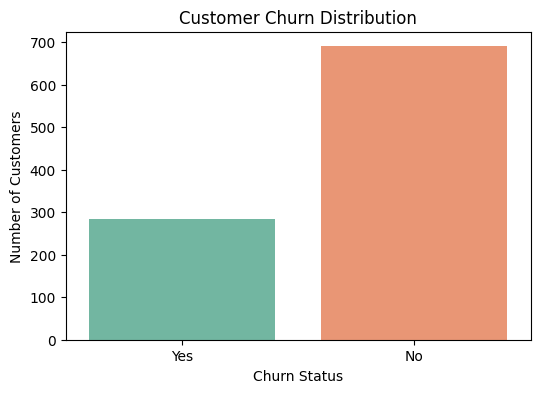

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Customer Churn Status', data=df, palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()


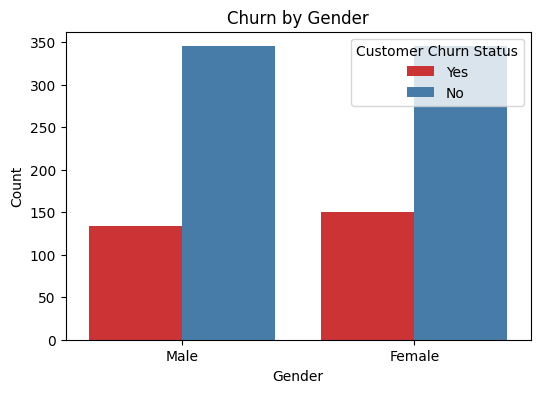

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Customer Churn Status', data=df, palette='Set1')
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


<Figure size 1200x500 with 0 Axes>

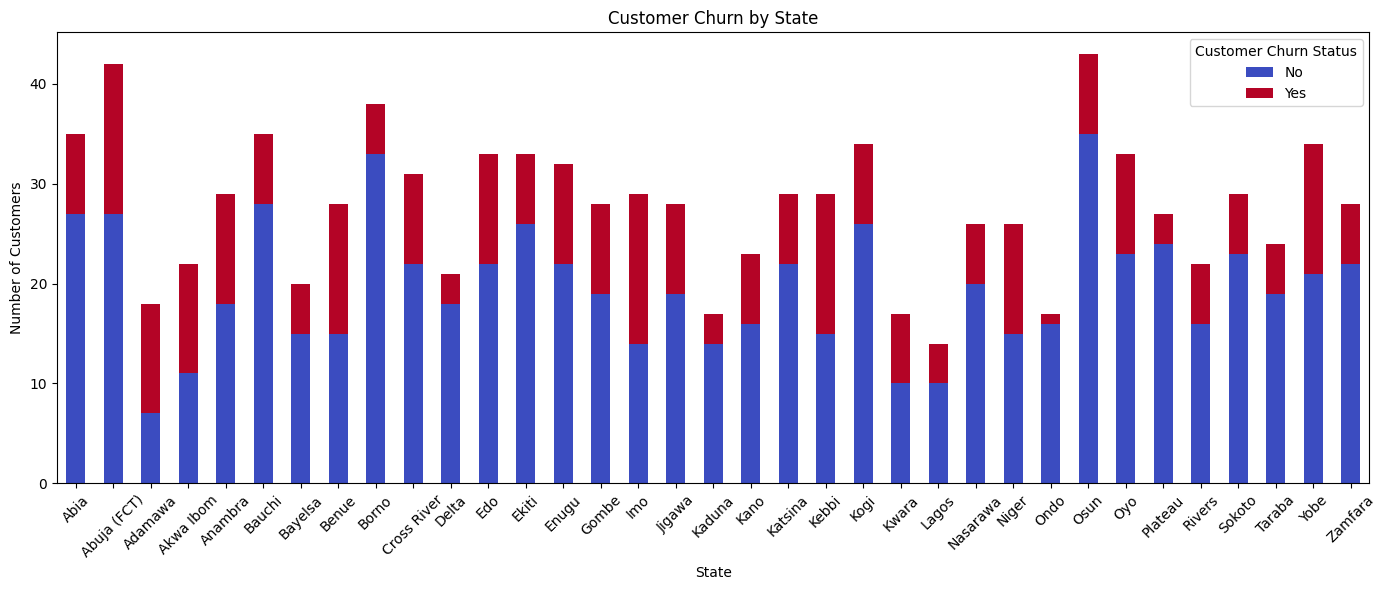

In [14]:
plt.figure(figsize=(12,5))
churn_by_state = df.groupby(['State', 'Customer Churn Status']).size().unstack()
churn_by_state.plot(kind='bar', stacked=True, figsize=(14,6), colormap='coolwarm')
plt.title('Customer Churn by State')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


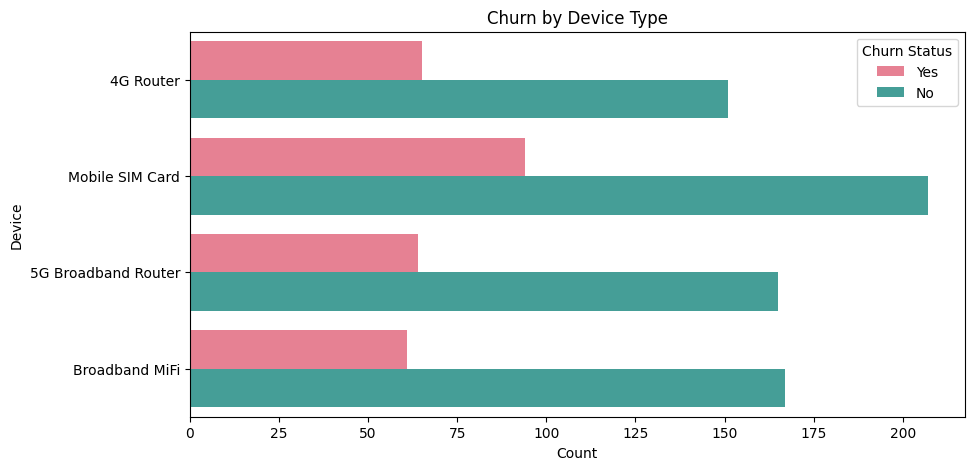

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(y='MTN Device', hue='Customer Churn Status', data=df, palette='husl')
plt.title('Churn by Device Type')
plt.xlabel('Count')
plt.ylabel('Device')
plt.legend(title='Churn Status')
plt.show()


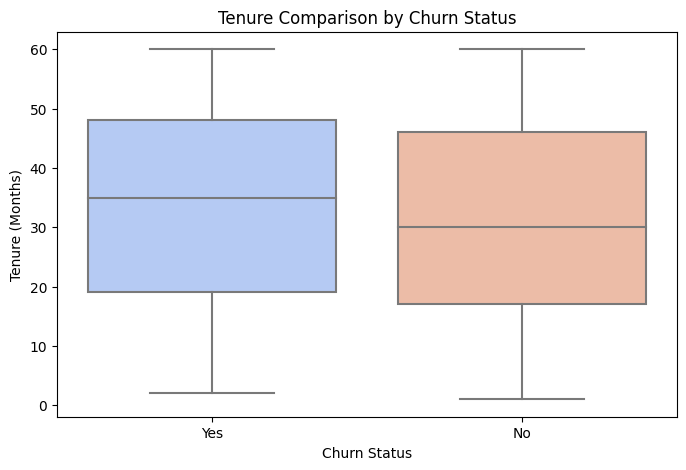

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Customer Churn Status', y='Customer Tenure in months', data=df, palette='coolwarm')
plt.title('Tenure Comparison by Churn Status')
plt.ylabel('Tenure (Months)')
plt.xlabel('Churn Status')
plt.show()


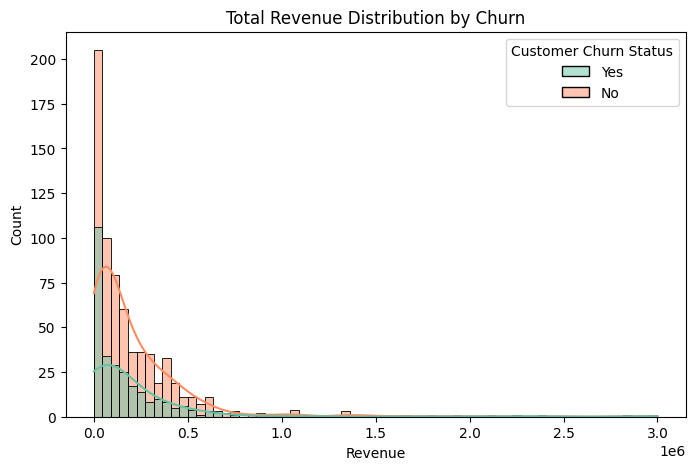

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Total Revenue', hue='Customer Churn Status', kde=True, palette='Set2')
plt.title('Total Revenue Distribution by Churn')
plt.xlabel('Revenue')
plt.show()


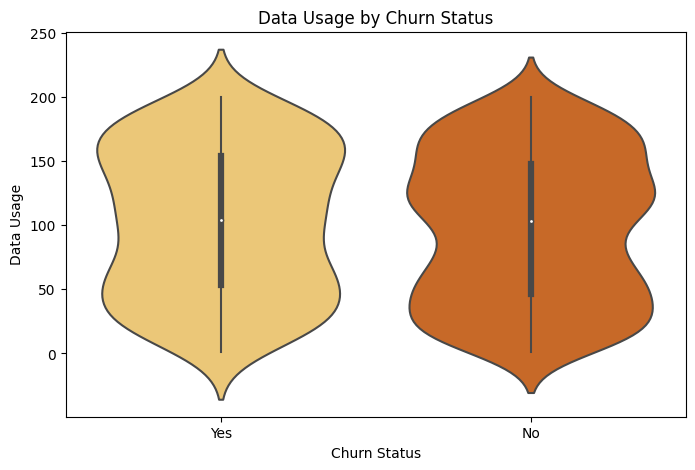

In [18]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Customer Churn Status', y='Data Usage', data=df, palette='YlOrBr')
plt.title('Data Usage by Churn Status')
plt.ylabel('Data Usage')
plt.xlabel('Churn Status')
plt.show()


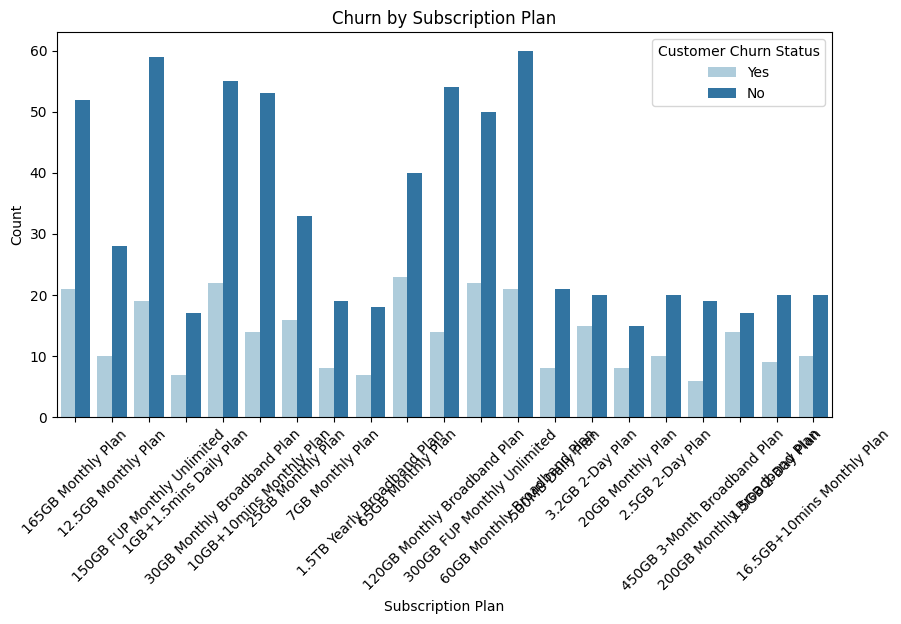

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(x='Subscription Plan', hue='Customer Churn Status', data=df, palette='Paired')
plt.title('Churn by Subscription Plan')
plt.xlabel('Subscription Plan')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


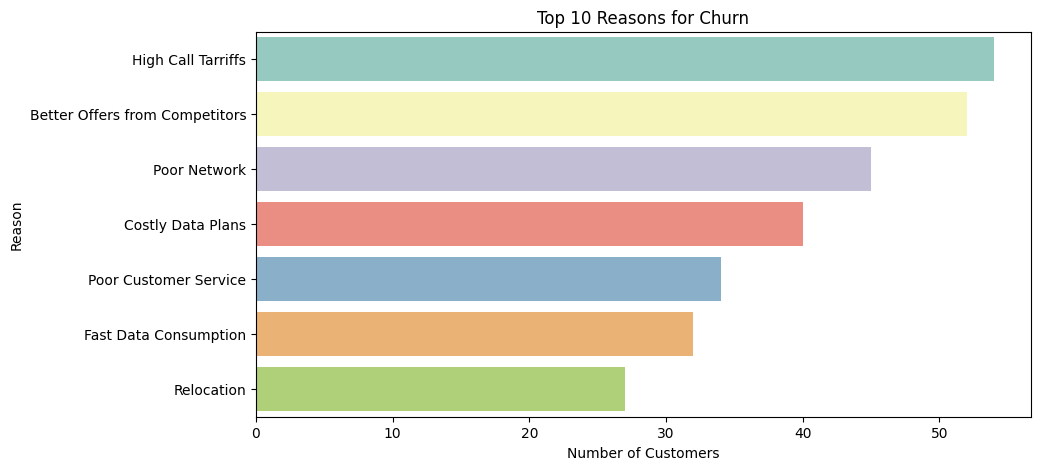

In [20]:
plt.figure(figsize=(10,5))
top_reasons = df['Reasons for Churn'].value_counts().head(10)
sns.barplot(x=top_reasons.values, y=top_reasons.index, palette='Set3')
plt.title('Top 10 Reasons for Churn')
plt.xlabel('Number of Customers')
plt.ylabel('Reason')
plt.show()


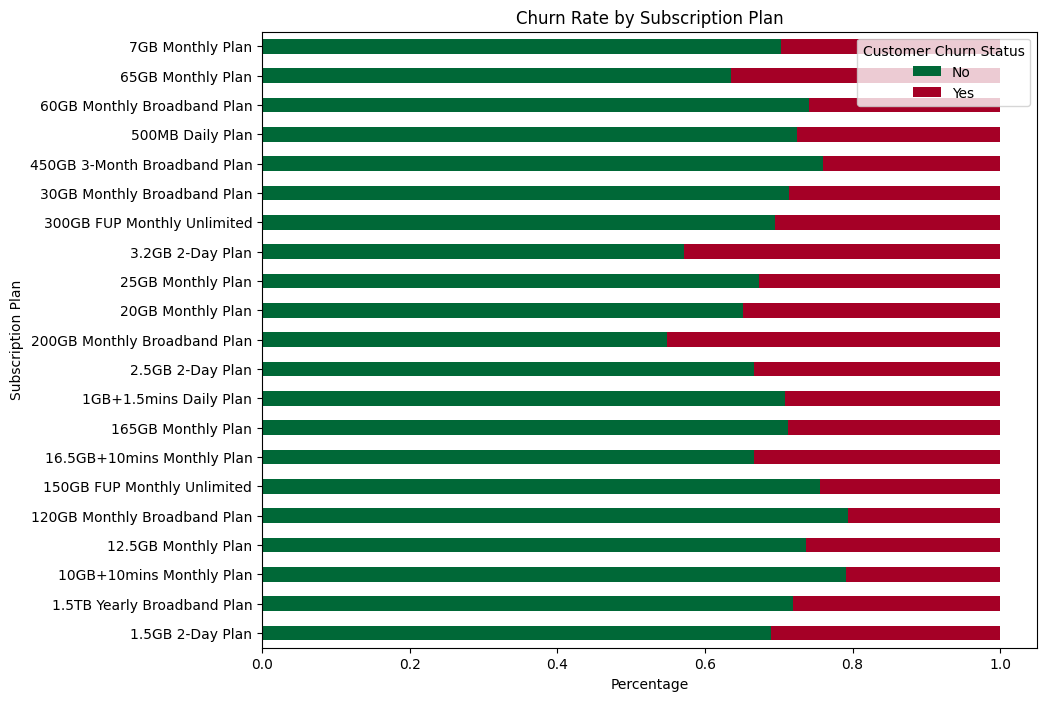

In [21]:
churn_rate_by_plan = df.groupby('Subscription Plan')['Customer Churn Status'].value_counts(normalize=True).unstack().fillna(0)
churn_rate_by_plan.plot(kind='barh', stacked=True, figsize=(10,8), colormap='RdYlGn_r')
plt.title('Churn Rate by Subscription Plan')
plt.xlabel('Percentage')
plt.show()


In [22]:
df['Revenue_per_Month'] = df['Total Revenue'] / df['Customer Tenure in months']


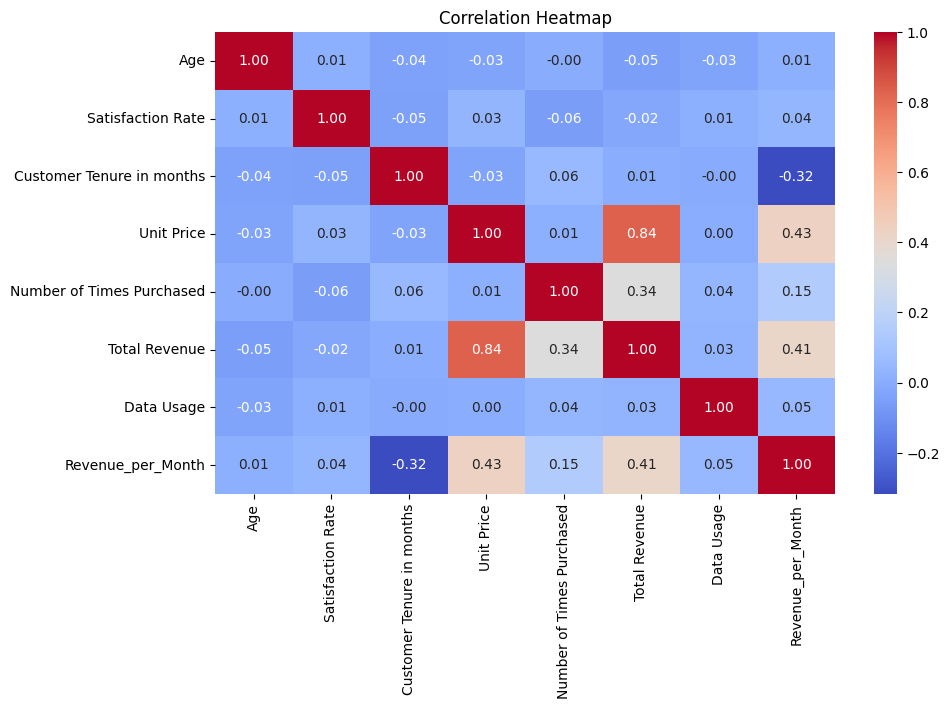

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Predictive modeling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [25]:
print("Class distribution before split:")
print(df["Customer Churn Status"].value_counts())


Class distribution before split:
Customer Churn Status
No     690
Yes    284
Name: count, dtype: int64


In [26]:
# Define the target column
target_col = 'Customer Churn Status'

# Drop non-predictive columns
cols_to_drop = [target_col, 'Date of Purchase', 'Customer ID', 'Full Name', 'Customer Review', 'Reasons for Churn']
existing_drop_cols = [col for col in cols_to_drop if col in df.columns]
predictor_cols = [col for col in df.columns if col not in existing_drop_cols]

# One-hot encoding for categorical features
if len(predictor_cols) > 0:
    df_model = pd.get_dummies(df[predictor_cols], drop_first=True)
else:
    raise ValueError('No predictor columns found after dropping non-predictive columns.')

X = df_model.copy()

# Create target variable
if target_col in df.columns:
    y = df[target_col].apply(lambda x: 1 if isinstance(x, str) and x.strip().lower() in ['churn', 'yes'] else 0)
else:
    raise ValueError(f'Target column {target_col} not found in data.')

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

if X.shape[0] == 0:
    raise ValueError('The feature matrix is empty. Check data cleaning steps.')

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

# Class distribution check
print("\nClass distribution in full data:\n", y.value_counts(normalize=True))
print("Class distribution in training set:\n", y_train.value_counts(normalize=True))
print("Class distribution in test set:\n", y_test.value_counts(normalize=True))


Feature matrix shape: (974, 66)
Target vector shape: (974,)
Training set shape: (681, 66)
Test set shape: (293, 66)

Class distribution in full data:
 Customer Churn Status
0    0.708419
1    0.291581
Name: proportion, dtype: float64
Class distribution in training set:
 Customer Churn Status
0    0.707783
1    0.292217
Name: proportion, dtype: float64
Class distribution in test set:
 Customer Churn Status
0    0.709898
1    0.290102
Name: proportion, dtype: float64



Logistic Regression Accuracy: 0.7099


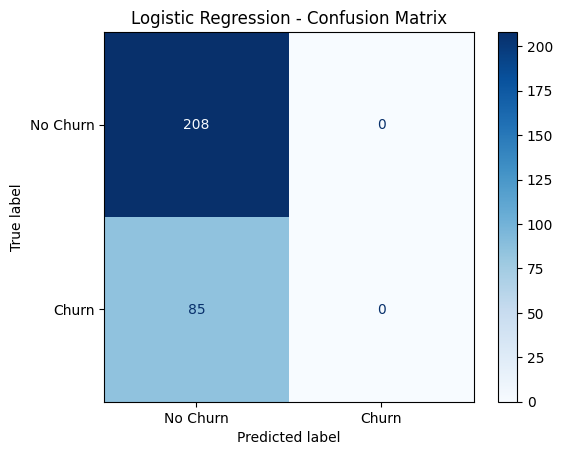


Random Forest Accuracy: 0.6997


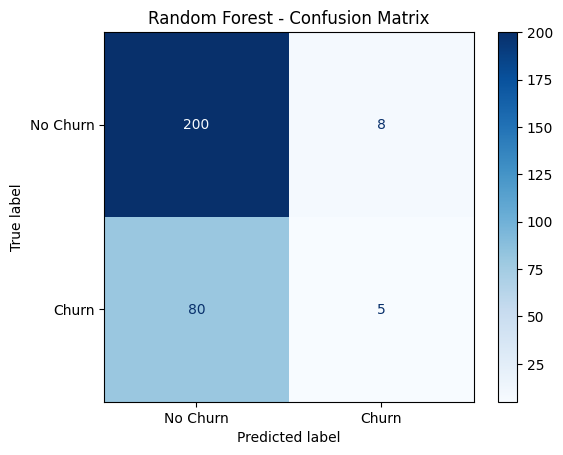


SVM (RBF Kernel) Accuracy: 0.7031


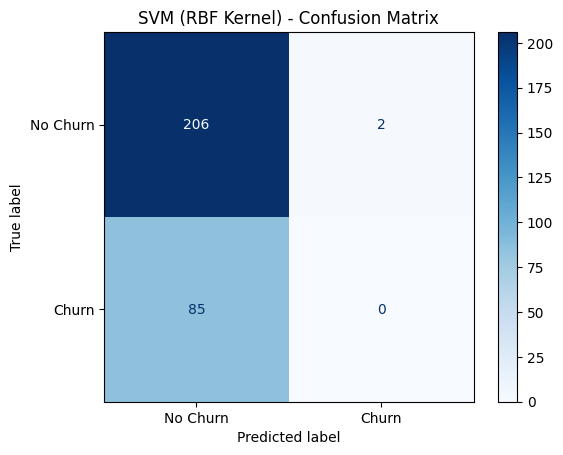


Decision Tree Accuracy: 0.6860


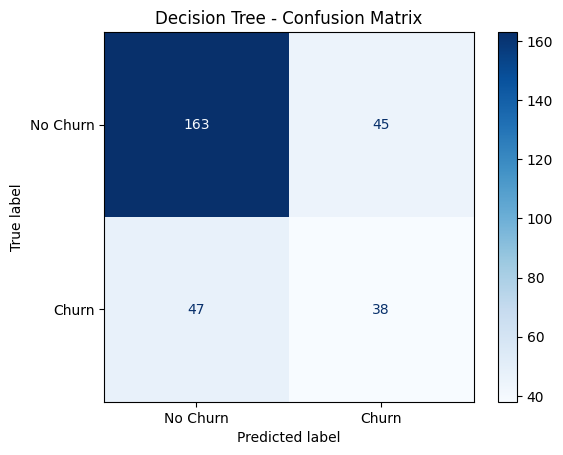


Naive Bayes Accuracy: 0.6655


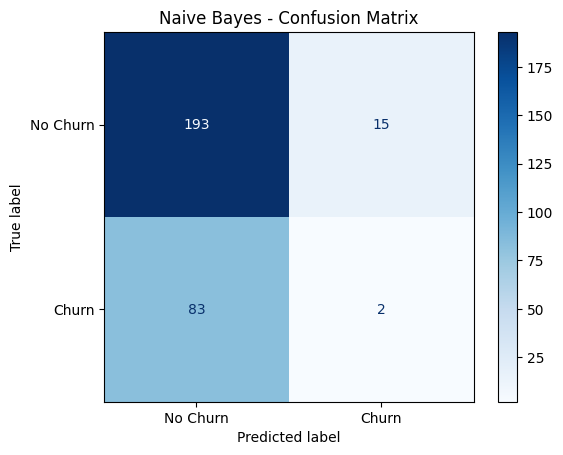


KNN Accuracy: 0.6348


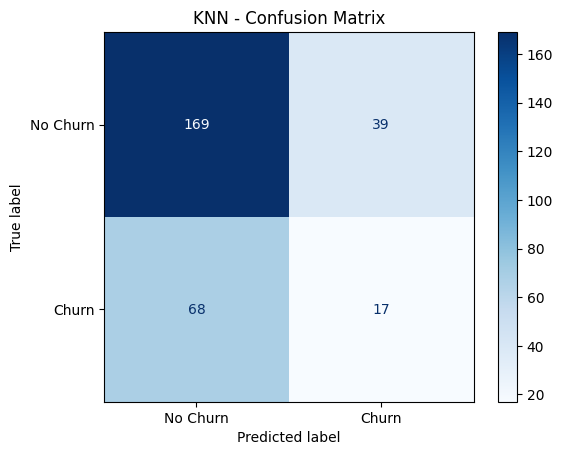

In [27]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"\n{name} Accuracy: {acc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

## Thank you..pls upvote!!